# L08B follow-along: factor, preserve, reuse

This notebook follows the lecture's three most reusable CNN design moves:

1. **Factor** a standard convolution into depthwise spatial filtering and pointwise channel mixing.
2. **Preserve** an identity path and learn only a residual correction.
3. **Reuse** a backbone under explicit weight/state contracts, then let validation choose how much to adapt.

For each part: **predict → calculate → run → inspect → explain**. The notebook keeps two evidence lanes separate:

- **Lane A · mechanics:** seeded synthetic tensors isolate shapes, gradients, optimizer membership, and module state.
- **Lane B · measured evidence:** a compact committed bundle records a real six-breed Oxford-IIIT Pet experiment with pretrained ResNet-18 features.

Core execution never downloads the dataset archive or model checkpoint and never invokes the evidence builder. If repository assets are absent (as in direct Colab), one clearly labeled cell fetches a compact committed evidence bundle and rejects any file that fails its SHA-256 contract. Lane B contains train/validation features but deliberately contains **no test features**; it inspects the one post-selection sealed-test evaluation already recorded in the bundle.

## Lane A · Synthetic mechanics under controlled inputs

This lane answers *what changed and why* with the smallest inspectable examples. It is causal evidence about mechanics, not evidence that a random representation transfers well.

## 0 · Setup

Before running the next cell, predict which number will be larger: the parameter reduction from a depthwise-separable convolution, or the ratio $C_{out}/k^2$? We will derive the exact answer.

In [1]:
import copy
import math
import random

import numpy as np
import torch
from torch import nn

SEED = 8
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_printoptions(precision=4, sci_mode=False)


def n_params(module, *, trainable_only=False):
    params = module.parameters()
    if trainable_only:
        params = (p for p in params if p.requires_grad)
    return sum(p.numel() for p in params)

print(f"torch={torch.__version__}; seed={SEED}")

torch=2.13.0; seed=8


## 1 · Factor one expensive convolution

We use exactly the lecture example:

- input feature map: $28\times28\times64$;
- output feature map: $28\times28\times128$;
- kernel: $3\times3$;
- bias omitted.

**Predict before running:**

- Standard weights: $3\cdot3\cdot64\cdot128 = \;?$  
- Depthwise weights: $3\cdot3\cdot64 = \;?$  
- Pointwise weights: $64\cdot128 = \;?$  
- Will both implementations return the same output *shape*?

In [2]:
H = W = 28
k = 3
c_in = 64
c_out = 128

standard_weights = k * k * c_in * c_out
depthwise_weights = k * k * c_in
pointwise_weights = c_in * c_out
separable_weights = depthwise_weights + pointwise_weights

standard_macs = H * W * standard_weights
separable_macs = H * W * separable_weights

print(f"standard weights : {standard_weights:>10,}")
print(f"depthwise weights: {depthwise_weights:>10,}")
print(f"pointwise weights: {pointwise_weights:>10,}")
print(f"separable total  : {separable_weights:>10,}")
print(f"parameter ratio : {standard_weights / separable_weights:>10.3f}×")
print(f"standard MACs   : {standard_macs:>10,}")
print(f"separable MACs  : {separable_macs:>10,}")

assert (standard_weights, separable_weights) == (73_728, 8_768)
assert (standard_macs, separable_macs) == (57_802_752, 6_874_112)

standard weights :     73,728
depthwise weights:        576
pointwise weights:      8,192
separable total  :      8,768
parameter ratio :      8.409×
standard MACs   : 57,802,752
separable MACs  :  6,874,112


### Run the two node paths

A standard convolution mixes space and channels in one operation. The separable path exposes two nodes:

$$x\;\longrightarrow\;\text{depthwise }3\!\times\!3\;\longrightarrow\;\text{pointwise }1\!\times\!1\;\longrightarrow\;y.$$

The values need not match because the weights are independently initialized. The **contract** to verify is the shape.

In [3]:
standard = nn.Conv2d(c_in, c_out, kernel_size=k, padding=1, bias=False)
separable = nn.Sequential(
    nn.Conv2d(c_in, c_in, kernel_size=k, padding=1, groups=c_in, bias=False),
    nn.Conv2d(c_in, c_out, kernel_size=1, bias=False),
)

x = torch.randn(2, c_in, H, W)
y_standard = standard(x)
y_depthwise = separable[0](x)
y_separable = separable(x)

print("input       ", tuple(x.shape))
print("depthwise   ", tuple(y_depthwise.shape))
print("standard out", tuple(y_standard.shape))
print("separable out", tuple(y_separable.shape))
print("module parameters:", n_params(standard), n_params(separable))

assert y_standard.shape == y_separable.shape == (2, 128, 28, 28)
assert y_depthwise.shape == (2, 64, 28, 28)
assert n_params(standard) == standard_weights
assert n_params(separable) == separable_weights

input        (2, 64, 28, 28)
depthwise    (2, 64, 28, 28)
standard out (2, 128, 28, 28)
separable out (2, 128, 28, 28)
module parameters: 73728 8768


### Explain

Write one sentence for each blank before revealing your notes:

1. The depthwise node changes ______ but not ______.  
2. The pointwise node changes ______ by mixing ______.  
3. The factorized block is cheaper because it avoids learning a separate $3\times3$ kernel for every ______.

Expected ideas: the depthwise node changes spatial responses but not channel count; the pointwise node changes channel count by mixing channels; the avoided object is every input–output channel pair.

## 2 · Preserve an identity path

The lecture used the scalar residual block

$$y=x+F(x), \qquad F(x)=\alpha x^2.$$

**Predict before running:** at $x=2$ and $\alpha=0.1$, what are $F(x)$, $y$, and $dy/dx$? What happens when $\alpha=0$?

In [4]:
def residual_scalar(x, alpha):
    return x + alpha * x.square()

x_scalar = torch.tensor(2.0, requires_grad=True)
alpha = torch.tensor(0.1)
y_scalar = residual_scalar(x_scalar, alpha)
y_scalar.backward()

print(f"x={x_scalar.item():.1f}")
print(f"F(x)={(alpha * x_scalar.detach().square()).item():.1f}")
print(f"y=x+F(x)={y_scalar.item():.1f}")
print(f"dy/dx={x_scalar.grad.item():.1f}")

assert math.isclose(y_scalar.item(), 2.4, rel_tol=1e-6)
assert math.isclose(x_scalar.grad.item(), 1.4, rel_tol=1e-6)

x=2.0
F(x)=0.4
y=x+F(x)=2.4
dy/dx=1.4


In [5]:
x_identity = torch.tensor([-2.0, 0.5, 3.0], requires_grad=True)
alpha_zero = torch.tensor(0.0)
y_identity = residual_scalar(x_identity, alpha_zero)
y_identity.sum().backward()

print("input :", x_identity.detach())
print("output:", y_identity.detach())
print("gradient through the block:", x_identity.grad)

assert torch.equal(y_identity.detach(), x_identity.detach())
assert torch.equal(x_identity.grad, torch.ones_like(x_identity))

input : tensor([-2.0000,  0.5000,  3.0000])
output: tensor([-2.0000,  0.5000,  3.0000])
gradient through the block: tensor([1., 1., 1.])


### Inspect the result

At $\alpha=0$, the residual branch contributes zero, so the forward map is the identity. The derivative is still one because the shortcut remains. This is the concrete meaning of “the identity path survives.”

**Misconception check:** the shortcut does not stop learning. When $\alpha\neq0$, the output and gradient both include the learned residual term.

## 3 · Reuse a backbone, replace the head

The lecture's held case uses a backbone feature $h\in\mathbb{R}^{512}$ and $K=6$ new classes, so the replacement head has $6\cdot512+6=3{,}078$ parameters. We reproduce that exact interface with a small local CNN containing BatchNorm.

> This backbone is randomly initialized. It is a fast, inspectable stand-in for checking shapes, gradients, parameter updates, and module state; it cannot demonstrate that transferred features are useful. Transfer quality requires a genuinely pretrained backbone and held-out validation data.

**Predict before running:** after setting `requires_grad=False` on every backbone parameter, which parameters can change? If the frozen backbone remains in training mode, can a BatchNorm running-mean buffer still change?

In [6]:
class TinyBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
        )
        self.late = nn.Sequential(
            nn.Conv2d(8, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(16, 512),
        )

    def forward(self, x):
        return self.late(self.stem(x))


class TransferClassifier(nn.Module):
    def __init__(self, n_classes=6):
        super().__init__()
        self.backbone = TinyBackbone()
        self.head = nn.Linear(512, n_classes)

    def forward(self, x):
        return self.head(self.backbone(x))


model = TransferClassifier(n_classes=6)
for parameter in model.backbone.parameters():
    parameter.requires_grad = False

lecture_backbone_parameters = 11_000_000
expected_head_parameters = 6 * 512 + 6
probe_fraction = expected_head_parameters / (lecture_backbone_parameters + expected_head_parameters)

features = model.backbone(torch.randn(2, 3, 16, 16))
logits = model.head(features)
print("feature shape        :", tuple(features.shape))
print("logit shape          :", tuple(logits.shape))
print(f"new head parameters : 6×512 + 6 = {n_params(model.head):,}")
print(f"all parameters      : {n_params(model):,}")
print(f"trainable parameters: {n_params(model, trainable_only=True):,}")
print(f"lecture probe share : {100 * probe_fraction:.3f}% of 11M + head")

assert features.shape == (2, 512)
assert logits.shape == (2, 6)
assert n_params(model.head) == expected_head_parameters == 3_078
assert n_params(model, trainable_only=True) == 3_078
assert math.isclose(100 * probe_fraction, 0.027974, rel_tol=1e-5)

feature shape        : (2, 512)
logit shape          : (2, 6)
new head parameters : 6×512 + 6 = 3,078
all parameters      : 13,222
trainable parameters: 3,078
lecture probe share : 0.028% of 11M + head


### Freezing weights is not freezing module state

`requires_grad=False` prevents parameter gradients and optimizer updates. It does **not** switch BatchNorm or Dropout to inference behaviour: `train()`/`eval()` controls that separate contract.

The next cell first shows that a frozen BatchNorm buffer can move in training mode. It then restores the state and performs a proper linear-probe step with the backbone in evaluation mode and the head in training mode. **Predict:** which of the four reported changes should be exactly zero?

In [7]:
images = torch.randn(12, 3, 16, 16)
labels = torch.tensor([0, 1, 2, 3, 4, 5] * 2)

# A parameter freeze alone does not freeze BatchNorm buffers.
clean_backbone_state = copy.deepcopy(model.backbone.state_dict())
stem_bn = model.backbone.stem[1]
running_mean_before = stem_bn.running_mean.detach().clone()
model.backbone.train()
with torch.no_grad():
    _ = model.backbone(images)
train_mode_bn_change = (stem_bn.running_mean - running_mean_before).abs().max().item()

# Restore state, then use the full linear-probe contract.
model.backbone.load_state_dict(clean_backbone_state)
model.head.train()
model.backbone.eval()
backbone_before = {name: p.detach().clone() for name, p in model.backbone.named_parameters()}
head_before = {name: p.detach().clone() for name, p in model.head.named_parameters()}
running_mean_before = stem_bn.running_mean.detach().clone()

probe_optimizer = torch.optim.SGD(model.head.parameters(), lr=0.2)
criterion = nn.CrossEntropyLoss()

probe_optimizer.zero_grad()
logits = model(images)
loss = criterion(logits, labels)
loss.backward()
probe_optimizer.step()

backbone_change = max(
    (p.detach() - backbone_before[name]).abs().max().item()
    for name, p in model.backbone.named_parameters()
)
head_change = max(
    (p.detach() - head_before[name]).abs().max().item()
    for name, p in model.head.named_parameters()
)
eval_mode_bn_change = (stem_bn.running_mean - running_mean_before).abs().max().item()
backbone_grad_is_none = all(p.grad is None for p in model.backbone.parameters())

print(f"frozen BN buffer change in train mode: {train_mode_bn_change:.6f}")
print(f"linear-probe loss                    : {loss.item():.4f}")
print(f"backbone parameter change            : {backbone_change:.6f}")
print(f"backbone BN change in eval mode      : {eval_mode_bn_change:.6f}")
print(f"head parameter change                : {head_change:.6f}")
print(f"backbone gradients are None          : {backbone_grad_is_none}")

assert train_mode_bn_change > 0.0
assert backbone_change == 0.0
assert eval_mode_bn_change == 0.0
assert head_change > 0.0
assert backbone_grad_is_none

frozen BN buffer change in train mode: 0.011999
linear-probe loss                    : 1.7955
backbone parameter change            : 0.000000
backbone BN change in eval mode      : 0.000000
head parameter change                : 0.004505
backbone gradients are None          : True


### Explain the update

- The frozen backbone still performed a forward computation; “frozen” means **not updated**, not “unused.”
- Its parameters had `requires_grad=False`, so no parameter gradients were stored and the optimizer contained only the head.
- BatchNorm running statistics are buffers, not parameters. They moved when the frozen backbone was in training mode and stayed fixed after `backbone.eval()`. Dropout would likewise remain stochastic in training mode.
- The trainable head received gradients and changed after the optimizer step. In a loop, call `model.train()` and then `model.backbone.eval()` on every linear-probe epoch, because `model.train()` recursively reactivates descendants.

This verifies mechanics only. It does not show that a random backbone transfers useful features.

## 4 · Let validation control progressive unfreezing

Do not unfreeze because a fixed epoch number elapsed, and never consult the test set. First train the probe while monitoring a held-out validation split. If training and validation both plateau at a poor level with only a small gap, the frozen representation may be the bottleneck; then unfreeze one late block and revalidate. A widening train–validation gap argues for more regularization or data, not more trainable capacity.

The trace below is an **illustrative control input**, not a result produced by the synthetic tensors above. **Predict before running:** will its small validation improvement and small train–validation gap keep the probe frozen or trigger one late-block unfreeze?

In [8]:
probe_train_loss = np.array([1.70, 1.56, 1.50, 1.49])
probe_val_loss = np.array([1.74, 1.59, 1.520, 1.519])
min_delta = 0.005
max_small_gap = 0.05
target_val_loss = 1.00  # a task-specific target chosen before inspecting the test set

recent_val_improvement = probe_val_loss[-2] - probe_val_loss[-1]
final_generalization_gap = probe_val_loss[-1] - probe_train_loss[-1]
still_below_target = probe_val_loss[-1] > target_val_loss
unfreeze_late = (
    recent_val_improvement < min_delta
    and final_generalization_gap < max_small_gap
    and still_below_target
)
decision = "unfreeze one late block" if unfreeze_late else "keep the linear probe"

print(f"recent validation improvement: {recent_val_improvement:.3f}")
print(f"final train–validation gap   : {final_generalization_gap:.3f}")
print(f"validation target met        : {not still_below_target}")
print("validation-controlled decision:", decision)

assert unfreeze_late
for parameter in model.backbone.late.parameters():
    parameter.requires_grad = True

late_parameters = [p for p in model.backbone.late.parameters() if p.requires_grad]
head_parameters = [p for p in model.head.parameters() if p.requires_grad]
fine_tune_optimizer = torch.optim.SGD(
    [
        {"params": late_parameters, "lr": 0.01, "name": "late_backbone"},
        {"params": head_parameters, "lr": 0.10, "name": "head"},
    ]
)
print("optimizer groups:", [(g["name"], g["lr"]) for g in fine_tune_optimizer.param_groups])

# One bounded mechanics step: frozen stem fixed; late block and head update.
model.train()
model.backbone.stem.eval()
stem_before = {name: p.detach().clone() for name, p in model.backbone.stem.named_parameters()}
late_before = {name: p.detach().clone() for name, p in model.backbone.late.named_parameters()}
head_before = {name: p.detach().clone() for name, p in model.head.named_parameters()}

fine_tune_optimizer.zero_grad()
fine_tune_loss = criterion(model(images), labels)
fine_tune_loss.backward()
fine_tune_optimizer.step()

def largest_parameter_change(module, before):
    return max(
        (parameter.detach() - before[name]).abs().max().item()
        for name, parameter in module.named_parameters()
    )

stem_change = largest_parameter_change(model.backbone.stem, stem_before)
late_change = largest_parameter_change(model.backbone.late, late_before)
head_change = largest_parameter_change(model.head, head_before)
print(f"frozen stem change : {stem_change:.6f}")
print(f"late block change  : {late_change:.6f}")
print(f"head change        : {head_change:.6f}")

assert [group["lr"] for group in fine_tune_optimizer.param_groups] == [0.01, 0.10]
assert stem_change == 0.0
assert late_change > 0.0
assert head_change > 0.0
assert all(p.grad is None for p in model.backbone.stem.parameters())

recent validation improvement: 0.001
final train–validation gap   : 0.029
validation target met        : False
validation-controlled decision: unfreeze one late block
optimizer groups: [('late_backbone', 0.01), ('head', 0.1)]
frozen stem change : 0.000000
late block change  : 0.000113
head change        : 0.001796


## Lane B · Measured real-image evidence

Lane A established mechanics with controlled synthetic inputs. Lane B asks a different question: **under one declared real-data protocol, how useful were pretrained features, and how much adaptation did validation select?**

Keep the evidence taxonomy explicit:

- **Observed:** an Oxford-IIIT Pet photograph and its official ResNet-18 preprocessing.
- **Model artifact:** the exact pretrained and validation-selected weight checkpoints.
- **Computed model output:** pretrained activations and post-selection predictions; neither is ground truth or saliency.
- **Measured:** train/validation curves from three fixed regimes and one sealed-test pass after validation selection.
- **Schematic:** explanatory arrows or layouts only; they are not measurements.

No image in this evidence case is generated. Before revealing the curves, commit to a regime—`probe`, `late`, or `all`—and name the validation evidence that could change your mind.

In [9]:
import csv
import hashlib
import json
import urllib.request
from pathlib import Path

from IPython.display import Image as DisplayImage
from IPython.display import SVG, display

EVIDENCE_REL = Path('shared/vision-evidence/oxford-iiit-pet/l8b')
RESULTS_SHA256 = '4e22a95b9567e0ac5a5839de33466429fc1668287479322c1e7d2de7f2847e23'
WEIGHTS_SHA256 = 'f37072fd47e89c5e827621c5baffa7500819f7896bbacec160b1a16c560e07ec'
REMOTE_BASE = 'https://raw.githubusercontent.com/nipunbatra/dl-teaching/master/'
BUNDLE_FILES = [
    'results.json',
    'selection-manifest.csv',
    'training-history.csv',
    'sealed-test-predictions.csv',
    'pretrained-trainval-features.npz',
    'preprocessing-contract.png',
    'resnet18-activations.png',
    'transfer-curves.svg',
    'sealed-test-examples.jpg',
]


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b''):
            digest.update(chunk)
    return digest.hexdigest()


def find_local_bundle():
    for root in [Path.cwd(), *Path.cwd().parents]:
        candidate = root / EVIDENCE_REL
        if (candidate / 'results.json').is_file():
            return candidate
    return None


evidence_dir = find_local_bundle()
if evidence_dir is None:
    evidence_dir = Path('/tmp/l08b-evidence-4e22a95b')
    evidence_dir.mkdir(parents=True, exist_ok=True)
    print('Repository assets absent: fetching the compact (<1 MiB), SHA-pinned evidence bundle.')
    print('This does NOT fetch Oxford archives, photographs, or ResNet weights, and does not run the builder.')
    for name in BUNDLE_FILES:
        target = evidence_dir / name
        urllib.request.urlretrieve(REMOTE_BASE + str(EVIDENCE_REL / name), target)
else:
    print('Using repository evidence:', EVIDENCE_REL)

assert sha256(evidence_dir / 'results.json') == RESULTS_SHA256
results = json.loads((evidence_dir / 'results.json').read_text())
for name in BUNDLE_FILES[1:]:
    expected = results['artifacts'][name]['sha256']
    assert sha256(evidence_dir / name) == expected, f'hash mismatch: {name}'
assert results['model']['weights_sha256'] == WEIGHTS_SHA256

bundle_bytes = sum((evidence_dir / name).stat().st_size for name in BUNDLE_FILES)
print(f'verified {len(BUNDLE_FILES)} files ({bundle_bytes / 2**20:.2f} MiB)')
print('status :', results['evidence_status'])
print('dataset:', results['dataset']['name'], '|', results['dataset']['license'])
print('model  :', results['model']['architecture'], results['model']['weights_enum'])
print('weights:', results['model']['weights_sha256'])
print('builder:', results['build']['builder_sha256'])

Using repository evidence: shared/vision-evidence/oxford-iiit-pet/l8b
verified 9 files (0.91 MiB)
status : measured fixed-subset teaching experiment; not a benchmark
dataset: Oxford-IIIT Pet | CC BY-SA 4.0; copyright remains with original image owners
model  : torchvision ResNet-18 ResNet18_Weights.IMAGENET1K_V1
weights: f37072fd47e89c5e827621c5baffa7500819f7896bbacec160b1a16c560e07ec
builder: 9fa630464dce7ef3907fe5653b0cbaed8a6889effee5dc742e54086db9c6da52


### Audit the split before looking at performance

The fixed teaching subset has six cat breeds. Training and validation are disjoint subselections of Oxford's official `trainval` split; the sealed subset comes from the official `test` split. Selection was locked by a seeded SHA-256 rank and every selected JPEG is bound by filename, dimensions, and content hash.

**Predict before running:** how many rows should be in the manifest, and why must the cached 512-D feature matrix have only 108 rows rather than 144?

In [10]:
from collections import Counter

with (evidence_dir / 'selection-manifest.csv').open(newline='') as handle:
    manifest = list(csv.DictReader(handle))

split_counts = Counter(row['teaching_split'] for row in manifest)
breed_split_counts = Counter((row['teaching_split'], row['breed']) for row in manifest)
assert split_counts == Counter({'train': 72, 'val': 36, 'test': 36})
assert all(breed_split_counts['train', breed] == 12 for breed in results['dataset']['breeds'])
assert all(breed_split_counts['val', breed] == 6 for breed in results['dataset']['breeds'])
assert all(breed_split_counts['test', breed] == 6 for breed in results['dataset']['breeds'])
assert all(row['official_split'] == 'trainval' for row in manifest if row['teaching_split'] != 'test')
assert all(row['official_split'] == 'test' for row in manifest if row['teaching_split'] == 'test')
assert len({row['filename'] for row in manifest}) == len(manifest) == 144
assert [int(row['manifest_index']) for row in manifest] == list(range(144))
assert sha256(evidence_dir / 'selection-manifest.csv') == results['dataset']['manifest_sha256']

feature_bundle = np.load(evidence_dir / 'pretrained-trainval-features.npz')
required_keys = {'features', 'labels', 'manifest_indices', 'teaching_splits', 'filenames', 'breeds'}
assert set(feature_bundle.files) == required_keys
feature_matrix = feature_bundle['features']
feature_labels = feature_bundle['labels']
feature_indices = feature_bundle['manifest_indices']
feature_splits = feature_bundle['teaching_splits'].astype(str)
feature_filenames = feature_bundle['filenames'].astype(str)
feature_breeds = feature_bundle['breeds'].astype(str)

assert feature_matrix.shape == (108, 512) and feature_matrix.dtype == np.float32
assert feature_labels.shape == feature_indices.shape == feature_splits.shape == feature_filenames.shape == (108,)
assert Counter(feature_splits) == Counter({'train': 72, 'val': 36})
assert 'test' not in set(feature_splits)
assert list(feature_breeds) == results['dataset']['breeds']
manifest_by_index = {int(row['manifest_index']): row for row in manifest}
for index, label, split, filename in zip(feature_indices, feature_labels, feature_splits, feature_filenames):
    row = manifest_by_index[int(index)]
    assert (int(row['label']), row['teaching_split'], row['filename']) == (int(label), split, filename)

print('manifest rows:', len(manifest), '| split counts:', dict(split_counts))
print('per breed    : train=12, validation=6, sealed test=6')
print('feature array :', feature_matrix.shape, feature_matrix.dtype)
print('feature splits:', dict(Counter(map(str, feature_splits))), '| contains test:', 'test' in set(feature_splits))
print('manifest SHA :', results['dataset']['manifest_sha256'])

manifest rows: 144 | split counts: {'train': 72, 'val': 36, 'test': 36}
per breed    : train=12, validation=6, sealed test=6
feature array : (108, 512) float32
feature splits: {'train': 72, 'val': 36} | contains test: False
manifest SHA : 5b5479a311cc2189522c478b4b2dbe014619f31831760ccadf419ddc41619f1e


### Inspect the exact preprocessing and representation hierarchy

The first figure is an **observed transformation** of the real shared photograph `Abyssinian_1.jpg`: resize the short side to 256, center-crop $224\times224$, convert RGB values to a tensor, and normalize with the official ImageNet mean and standard deviation. The second figure contains **computed pretrained activations**. Its selected channels are ranked by mean absolute activation and separately rescaled for display; they are **not saliency maps** and do not say which pixels caused a class decision.

source WH  : (600, 400)
resized WH : (384, 256) | short side = 256
crop WH    : (224, 224)
tensor CHW : (3, 224, 224) | batched NCHW = (1, 3, 224, 224)
mean/std   : [0.485, 0.456, 0.406] / [0.229, 0.224, 0.225]
normalized R: [-2.101, +1.992], mean=-0.590
normalized G: [-1.966, +1.851], mean=-0.530
normalized B: [-1.804, +2.135], mean=-0.652
activation CHW: {'layer1': (64, 56, 56), 'layer2': (128, 28, 28), 'layer4': (512, 7, 7)}
semantics     : computed pretrained activations; not saliency


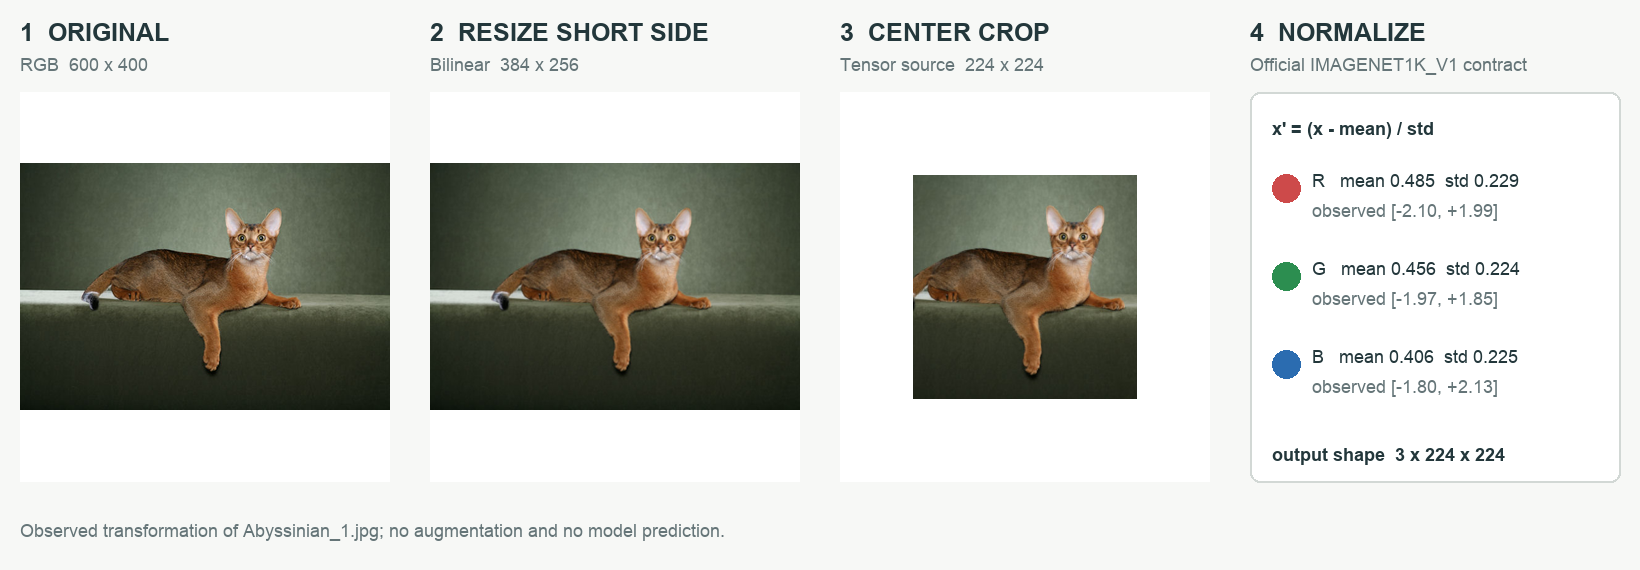

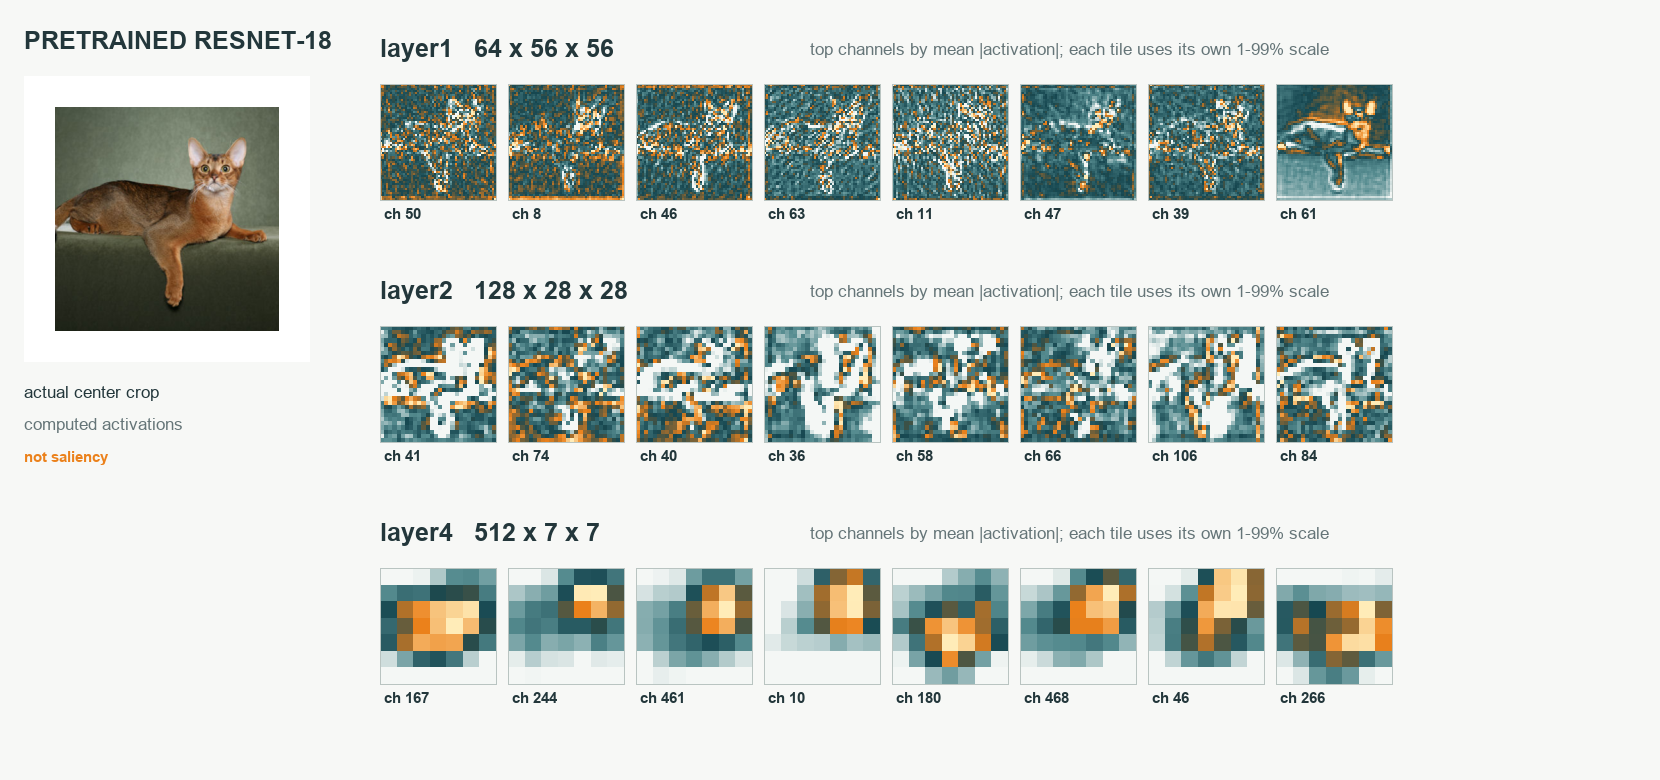

In [11]:
preprocess = results['preprocessing']
observed = preprocess['observed_shared_image']
print('source WH  :', tuple(observed['original_size_wh']))
print('resized WH :', tuple(observed['resized_size_wh']), '| short side =', preprocess['resize_size'][0])
print('crop WH    :', tuple(observed['crop_size_wh']))
print('tensor CHW :', tuple(observed['tensor_shape_chw']), '| batched NCHW =', (1, *observed['tensor_shape_chw']))
print('mean/std   :', preprocess['mean'], '/', preprocess['std'])
for stats in observed['channel_stats_after_normalization']:
    print(f"normalized {stats['channel']}: [{stats['min']:+.3f}, {stats['max']:+.3f}], mean={stats['mean']:+.3f}")

stages = results['activation_figure']['stages']
assert stages['layer1']['shape_chw'] == [64, 56, 56]
assert stages['layer2']['shape_chw'] == [128, 28, 28]
assert stages['layer4']['shape_chw'] == [512, 7, 7]
print('activation CHW:', {name: tuple(info['shape_chw']) for name, info in stages.items()})
print('semantics     :', results['activation_figure']['semantics'])

display(DisplayImage(filename=str(evidence_dir / 'preprocessing-contract.png'), width=980))
display(DisplayImage(filename=str(evidence_dir / 'resnet18-activations.png'), width=980))

### Reconstruct validation selection, then inspect the sealed result

All regimes share the same 15-epoch budget, seed, head initialization, minibatch order, optimizer family, preprocessing, and split. Only trainable scope and declared backbone learning rate change. Within a regime, validation chooses the epoch by accuracy, then lower loss, then earlier epoch. Across regimes, validation accuracy comes first; a tie prefers fewer trainable parameters, then lower loss and earlier epoch.

The next cell reconstructs that choice from `training-history.csv` **before** reading the stored test predictions. This is an audit of a completed experiment, not a fresh test-set model-selection loop.

probe | trainable      3,078 | best epoch 14 | val 33/36 = 91.7%
late  | trainable  8,396,806 | best epoch  4 | val 27/36 = 75.0%
all   | trainable 11,179,590 | best epoch 13 | val 34/36 = 94.4%
validation selected: all at epoch 13
sealed test opened once: 33/36 = 91.7%; loss=0.168423
caveat: measured fixed-subset teaching experiment; not a benchmark


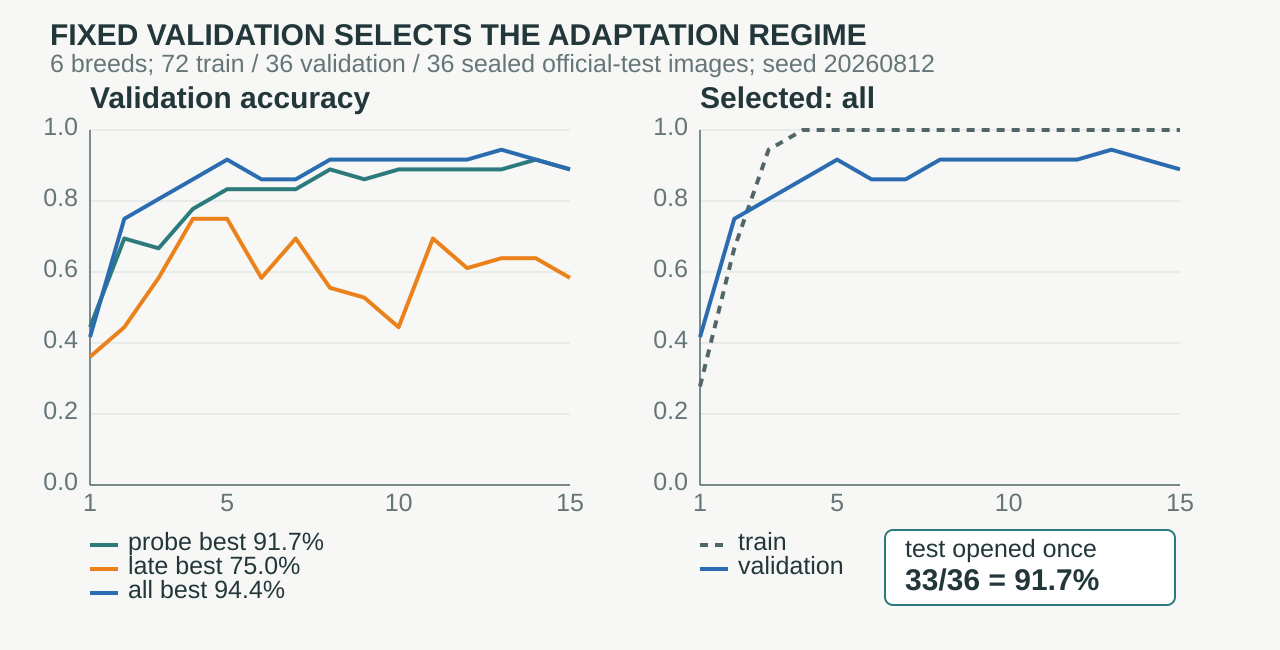

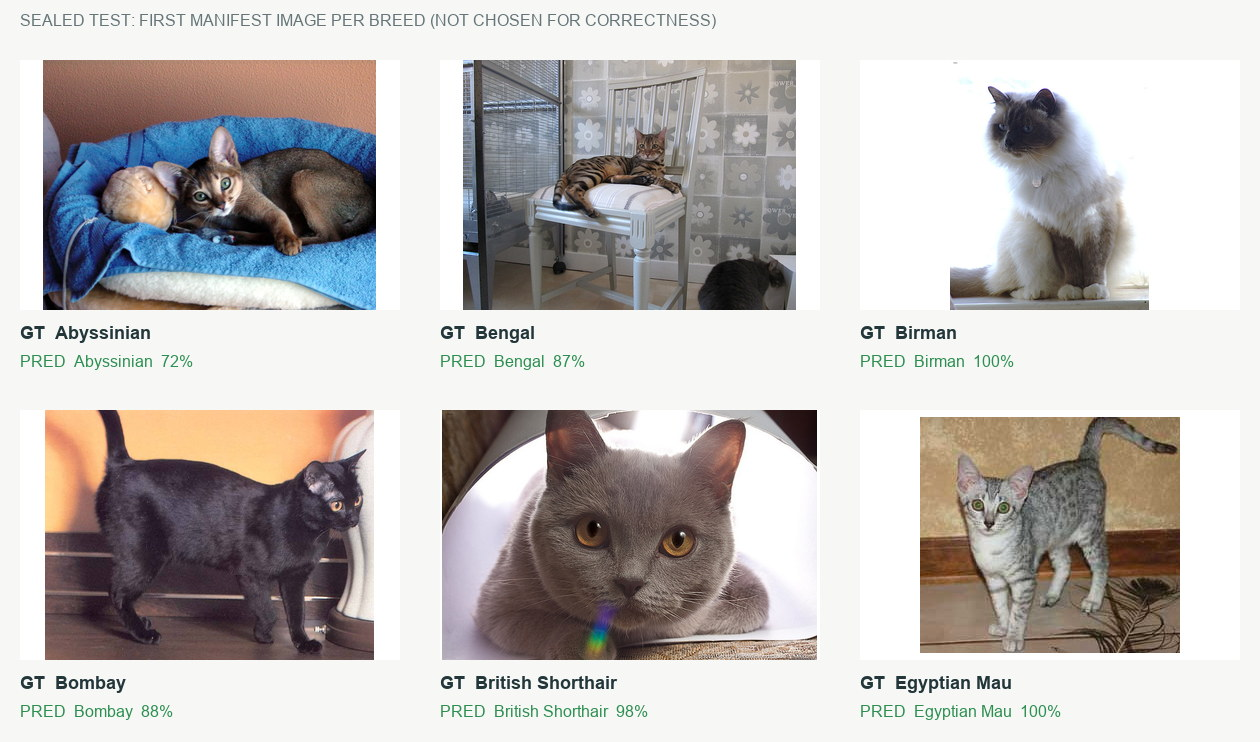

In [12]:
with (evidence_dir / 'training-history.csv').open(newline='') as handle:
    history = list(csv.DictReader(handle))
for row in history:
    row['epoch'] = int(row['epoch'])
    for key in ['train_loss', 'train_accuracy', 'val_loss', 'val_accuracy']:
        row[key] = float(row[key])

stored_regimes = {item['regime']: item for item in results['regimes']}
best_by_regime = {}
for regime in ['probe', 'late', 'all']:
    rows = [row for row in history if row['regime'] == regime]
    assert len(rows) == results['protocol']['epochs'] == 15
    best = max(rows, key=lambda row: (row['val_accuracy'], -row['val_loss'], -row['epoch']))
    best_by_regime[regime] = best
    stored = stored_regimes[regime]['best']
    assert best['epoch'] == stored['epoch']
    assert math.isclose(best['val_accuracy'], stored['val_accuracy'], abs_tol=1e-12)
    print(
        f"{regime:5s} | trainable {stored_regimes[regime]['trainable_parameters']:>10,} "
        f"| best epoch {best['epoch']:>2} | val {36 * best['val_accuracy']:.0f}/36 = {best['val_accuracy']:.1%}"
    )

selected_regime = max(
    best_by_regime,
    key=lambda regime: (
        best_by_regime[regime]['val_accuracy'],
        -stored_regimes[regime]['trainable_parameters'],
        -best_by_regime[regime]['val_loss'],
        -best_by_regime[regime]['epoch'],
    ),
)
selection = results['sealed_test_contract']
assert selected_regime == selection['selected_regime'] == 'all'
assert best_by_regime[selected_regime]['epoch'] == selection['selected_epoch'] == 13
assert selection['test_evaluations'] == 1 and selection['test_evaluated_after_selection']
print(f"validation selected: {selected_regime} at epoch {selection['selected_epoch']}")

# Only now inspect the already-recorded, single selected-checkpoint test pass.
with (evidence_dir / 'sealed-test-predictions.csv').open(newline='') as handle:
    predictions = list(csv.DictReader(handle))
test = results['selected_test']
assert len(predictions) == test['count'] == 36
assert sum(int(row['correct']) for row in predictions) == test['correct'] == 33
assert math.isclose(test['accuracy'], 33 / 36, abs_tol=1e-12)
for row in predictions:
    probability_sum = sum(float(row[f'prob_{breed}']) for breed in results['dataset']['breeds'])
    assert math.isclose(probability_sum, 1.0, abs_tol=2e-6)
print(f"sealed test opened once: {test['correct']}/{test['count']} = {test['accuracy']:.1%}; loss={test['loss']:.6f}")
print('caveat:', results['evidence_status'])

display(SVG(filename=str(evidence_dir / 'transfer-curves.svg')))
display(DisplayImage(filename=str(evidence_dir / 'sealed-test-examples.jpg'), width=980))

### Lightweight replay: the real linear probe, without images or a checkpoint

The committed $108\times512$ feature matrix was computed by the exact pretrained backbone for training and validation only. We can therefore replay the real `Linear(512, 6)` probe with the original seed, head initialization, minibatch order, AdamW settings, and selection rule. This reproduces the probe result without a model-weight or dataset download.

This replay **cannot** reproduce `late` or `all`: those regimes change the backbone and require pixels plus the checkpoint. It also cannot evaluate the test set, because test features were deliberately excluded. Their measured histories and the single sealed result remain builder-produced evidence, not notebook-generated claims.

In [13]:
from torch.utils.data import DataLoader, TensorDataset

REAL_SEED = results['protocol']['seed']
random.seed(REAL_SEED)
np.random.seed(REAL_SEED)
torch.manual_seed(REAL_SEED)
torch.use_deterministic_algorithms(True)

feature_tensor = torch.from_numpy(feature_matrix)
label_tensor = torch.from_numpy(feature_labels)
train_mask = feature_splits == 'train'
val_mask = feature_splits == 'val'
probe = nn.Linear(results['model']['feature_dimension'], len(feature_breeds))
optimizer = torch.optim.AdamW(
    probe.parameters(),
    lr=results['protocol']['learning_rates']['head_all_regimes'],
    weight_decay=results['protocol']['weight_decay'],
)
loader = DataLoader(
    TensorDataset(feature_tensor[train_mask], label_tensor[train_mask]),
    batch_size=results['protocol']['batch_size'],
    shuffle=True,
    generator=torch.Generator().manual_seed(REAL_SEED),
    num_workers=0,
)

replay_history = []
for epoch in range(1, results['protocol']['epochs'] + 1):
    probe.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_count = 0
    for batch_features, batch_labels in loader:
        optimizer.zero_grad(set_to_none=True)
        batch_logits = probe(batch_features)
        batch_loss = nn.functional.cross_entropy(batch_logits, batch_labels)
        batch_loss.backward()
        optimizer.step()
        train_loss_sum += batch_loss.item() * len(batch_labels)
        train_correct += int((batch_logits.argmax(1) == batch_labels).sum())
        train_count += len(batch_labels)
    probe.eval()
    with torch.inference_mode():
        val_logits = probe(feature_tensor[val_mask])
        val_loss = nn.functional.cross_entropy(val_logits, label_tensor[val_mask]).item()
        val_correct = int((val_logits.argmax(1) == label_tensor[val_mask]).sum())
    replay_history.append({
        'epoch': epoch,
        'train_loss': train_loss_sum / train_count,
        'train_accuracy': train_correct / train_count,
        'val_loss': val_loss,
        'val_accuracy': val_correct / int(val_mask.sum()),
        'val_correct': val_correct,
    })

replay_best = max(
    replay_history,
    key=lambda row: (row['val_accuracy'], -row['val_loss'], -row['epoch']),
)
stored_probe = stored_regimes['probe']['best']
assert replay_best['epoch'] == stored_probe['epoch'] == 14
assert replay_best['val_correct'] == 33
assert math.isclose(replay_best['val_accuracy'], stored_probe['val_accuracy'], abs_tol=1e-12)
assert math.isclose(replay_best['val_loss'], stored_probe['val_loss'], abs_tol=1e-4)

print('replay input      :', tuple(feature_tensor.shape), '| train=72, validation=36, test=0')
print('trainable head    : 512×6 + 6 =', n_params(probe))
print(f"replayed best    : epoch {replay_best['epoch']}, {replay_best['val_correct']}/36 = {replay_best['val_accuracy']:.1%}")
print(f"stored best      : epoch {stored_probe['epoch']}, val={stored_probe['val_accuracy']:.1%}")
print('test features     : absent by construction')

replay input      : (108, 512) | train=72, validation=36, test=0
trainable head    : 512×6 + 6 = 3078
replayed best    : epoch 14, 33/36 = 91.7%
stored best      : epoch 14, val=91.7%
test features     : absent by construction


### Interpret without overclaiming

On this fixed teaching subset, the pretrained probe was already strong: $33/36=91.7\%$ validation. Late-only adaptation was worse under the declared 15-epoch protocol ($27/36=75.0\%$), while full adaptation reached $34/36=94.4\%$ and therefore won the predeclared validation rule. Only that selected all-backbone checkpoint was evaluated on the sealed official-test subset, obtaining $33/36=91.7\%$.

What this supports: pretrained features are useful for these six breeds, and validation selected full adaptation under this exact small protocol. What it does **not** support: that full fine-tuning is generally superior, that `layer4` adaptation is intrinsically poor, or that $91.7\%$ estimates Oxford-IIIT Pet benchmark performance. The subset is tiny, selection was bootstrapped from available JPEGs, and this is a teaching experiment rather than a benchmark.

## 5 · Synthesis

Complete these explanations without architecture names:

1. Two stacked $3\times3$ convolutions can replace one $5\times5$ because ______.  
2. A $1\times1$ bottleneck saves compute by reducing ______ before ______.  
3. A residual shortcut makes ______ behaviour easy to represent.  
4. A depthwise-separable block factors ______ from ______.  
5. A linear probe tests whether pretrained ______ are already useful for new ______.  
6. Freezing parameters does not freeze BatchNorm ______ or Dropout ______; that requires the right module mode.  
7. The test set remains sealed while the ______ split controls whether a late block is unfrozen.

If you can answer these precisely—and reproduce the counts above—you understand the design reasoning behind the blocks, not merely their names.